# Imports

In [51]:
# General util imports
import os
from dotenv import load_dotenv
import kagglehub
import shutil
from pathlib import Path
import tkinter as tk
from tkinter import filedialog

# Math and ML imports
import pandas as pd
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np

# Visualization imports
from matplotlib import pyplot as plt
from matplotlib import patches
from matplotlib.lines import Line2D
from tqdm import tqdm

# Custom util imports
from merge_csvs import merge_csvs

# Kaggle setup and dataset download

In [2]:
# Get Kaggle credentials from .env
load_dotenv()
kaggle_username, kaggle_key = os.getenv("KAGGLE_USERNAME"), os.getenv("KAGGLE_KEY")

# Set credentials in os.environ so Kaggle API can find them automatically
if kaggle_username:
    os.environ["KAGGLE_USERNAME"] = kaggle_username
if kaggle_key:
    os.environ["KAGGLE_KEY"] = kaggle_key

if not kaggle_key:
    print("Warning: KAGGLE_KEY not found. Please set it as an environment variable.")

In [3]:
# Download dataset from Kaggle if not already downloaded
path = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\nerfb\.cache\kagglehub\datasets\awsaf49\cbis-ddsm-breast-cancer-image-dataset\versions\1


# Move data to local project

In [4]:
source_dir = Path(path)
target_dir = Path('../data/cbis-ddsm')

# Ensure the target directory exists and is empty
if not os.path.exists(target_dir):
    os.makedirs(target_dir)
if len(os.listdir(target_dir)) == 0:
    shutil.copytree(str(source_dir), str(target_dir),
                    dirs_exist_ok=True)  # Copy the data to the target directory instead of moving it
    print("Copied data to target location")

    # Merge Mass CSVs into a single file
    merge_csvs(['../data/cbis-ddsm/csv/mass_case_description_test_set.csv',
                '../data/cbis-ddsm/csv/mass_case_description_train_set.csv'],
               '../data/cbis-ddsm/csv/mass_case_description_merged.csv')
else:
    print("Target directory is not empty. Skipping data copy.")

Target directory is not empty. Skipping data copy.


# Create dataframes

In [23]:
# Full dataframe
df = pd.read_csv('../data/cbis-ddsm/csv/dicom_info.csv')

# Change image path to relative path
df['image_path'] = df['image_path'].apply(lambda x: x.replace('CBIS-DDSM/', '../data/cbis-ddsm/'))

# Remove calcification images. Only focusing on masses for now
df = df[~df['PatientID'].str.contains('Calc')]

# ROI mask dataframe
roi_masks_df = df[df['SeriesDescription'] == 'ROI mask images']

# Full mammogram dataframe
full_mammograms_df = df[df['SeriesDescription'] == 'full mammogram images']

print(f"Total ROIs: {len(roi_masks_df)}")
print(roi_masks_df['image_path'].head(5))

Total ROIs: 1696
14    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
20    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
22    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
31    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
34    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
Name: image_path, dtype: str


# Pair ROIs with full images

In [24]:
# Extract the base patient ID from each dataframe
roi_masks_df = roi_masks_df.copy()
roi_masks_df['base_id'] = roi_masks_df['PatientID'].str.extract(r'(.*_[A-Z]+_[A-Z]+)')

full_mammograms_df = full_mammograms_df.copy()
full_mammograms_df['base_id'] = full_mammograms_df['PatientID']

# Merge the two dataframes on the base_id column
merged_df = pd.merge(
    full_mammograms_df,
    roi_masks_df,
    on='base_id',
    suffixes=('_full', '_roi')
)

print(f"Successfully paired {len(merged_df)} mammogram/ROI pairs.")

initial_len = len(merged_df)
merged_df = merged_df[
    (merged_df['Rows_full'] == merged_df['Rows_roi']) &
    (merged_df['Columns_full'] == merged_df['Columns_roi'])
    ]
print(f"Removed {initial_len - len(merged_df)} entries due to mismatched dimensions.")

# Group ROIs of the same image together
paired_df = merged_df.groupby('image_path_full').agg({
    'image_path_roi': list,
    'PatientID_full': 'first',
    'base_id': 'first'
}).reset_index()

print(f"Consolidated into {len(paired_df)} image entries.")

Successfully paired 1696 mammogram/ROI pairs.
Removed 78 entries due to mismatched dimensions.
Consolidated into 1514 image entries.


In [25]:
paired_df.head(5)

,image_path_full,image_path_roi,PatientID_full,base_id
0,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Test_P_00576_LEFT_MLO,Mass-Test_P_00576_LEFT_MLO
1,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Test_P_01510_RIGHT_MLO,Mass-Test_P_01510_RIGHT_MLO
2,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Test_P_01294_RIGHT_MLO,Mass-Test_P_01294_RIGHT_MLO
3,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Training_P_00281_LEFT_MLO,Mass-Training_P_00281_LEFT_MLO
4,../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....,[../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...,Mass-Training_P_00106_RIGHT_MLO,Mass-Training_P_00106_RIGHT_MLO


# Check dataframe sizes

In [26]:
print("Original df: ", df.shape[0])

print("Mammograms: ", full_mammograms_df.shape[0])
print("ROI masks: ", roi_masks_df.shape[0])

print("Pairs: ", merged_df.shape[0])
print("Entries: ", paired_df.shape[0])

Original df:  5550
Mammograms:  1592
ROI masks:  1696
Pairs:  1618
Entries:  1514


# Custom Dataset class

This class converts the ROI masks into bounding boxes for use in a PyTorch RCNN model.

In [31]:
class CBISDDSM_RCNN_Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path_full']
        roi_paths = self.df.iloc[idx]['image_path_roi']

        # Load the mammogram image and convert to RGB
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load each ROI mask for the mammogram image
        boxes = []
        for r_path in roi_paths:
            # Read the mask and ensure it is the same size as the mammogram image
            mask = cv2.imread(r_path)
            mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

            pos = np.where(mask > 0)

            #Convert to bounding box format
            if len(pos[0]) > 0:
                xmin, xmax = np.min(pos[1]), np.max(pos[1])
                ymin, ymax = np.min(pos[0]), np.max(pos[0])
                boxes.append([xmin, ymin, xmax, ymax])

        labels = [1] * len(boxes) if boxes else []

        # Transform the image and bounding boxes
        if self.transform:
            transformed = self.transform(image=img, bboxes=boxes, labels=labels)
            img_tensor = transformed['image']

            if len(transformed['bboxes']) > 0:
                boxes = torch.as_tensor(transformed['bboxes'], dtype=torch.float32)
                labels = torch.as_tensor(transformed['labels'], dtype=torch.int64)
            else:
                boxes = torch.empty((0, 4), dtype=torch.float32)
                labels = torch.empty((0,), dtype=torch.int64)
        else:
            img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            boxes = torch.as_tensor(boxes, dtype=torch.float32) if len(boxes) > 0 else torch.empty((0, 4),
                                                                                                   dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        # Create the target dictionary
        target = {
            "boxes": boxes,
            "labels": labels,
            "img_id": torch.tensor([idx]),
        }

        return img_tensor, target

    def visualize_sample(self, idx, title=None):
        img_tensor, target = self[idx]

        try:
            img_np = img_tensor.permute(1, 2, 0).numpy()
        except:
            img_np = img_tensor.squeeze(0).numpy()

        fig, ax = plt.subplots(1, figsize=(10, 10))
        ax.imshow(img_np, cmap='gray')

        boxes = target["boxes"].numpy()

        for box in boxes:
            xmin, ymin, xmax, ymax = box
            width = xmax - xmin
            height = ymax - ymin

            rect = patches.Rectangle(
                (xmin, ymin),
                width,
                height,
                linewidth=2,
                edgecolor='r',
                facecolor='none'
            )

            ax.add_patch(rect)

            plt.text(xmin, ymin - 10, 'Abnormality', color='r', fontsize=12, weight='bold')

        plt.axis('off')
        plt.title("Sample Image and Bounding Box(es)" if not title else title)
        plt.show()


In [28]:
# Define the transform function
# Resizes the image to 1024x1024 pixels and converts it to float32 format with values between 0 and 1.
rcnn_transform = A.Compose([
    A.Resize(height=1_024, width=1_024),
    A.ToFloat(max_value=255.0),
    ToTensorV2()
],
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'])
)

# Check the transformed images and bounding boxes for errors

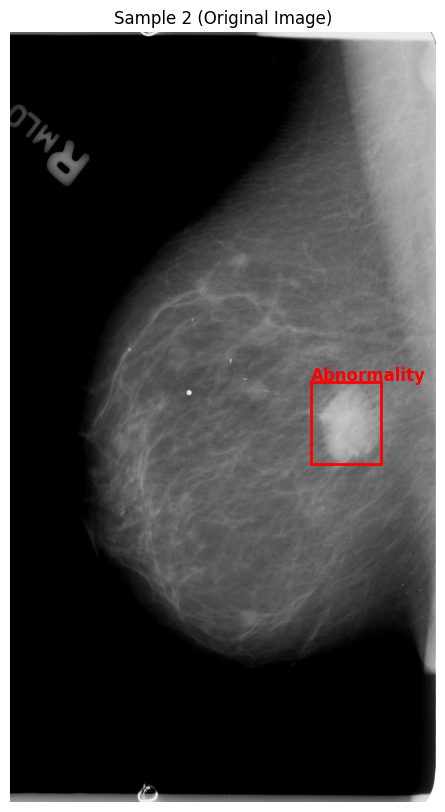

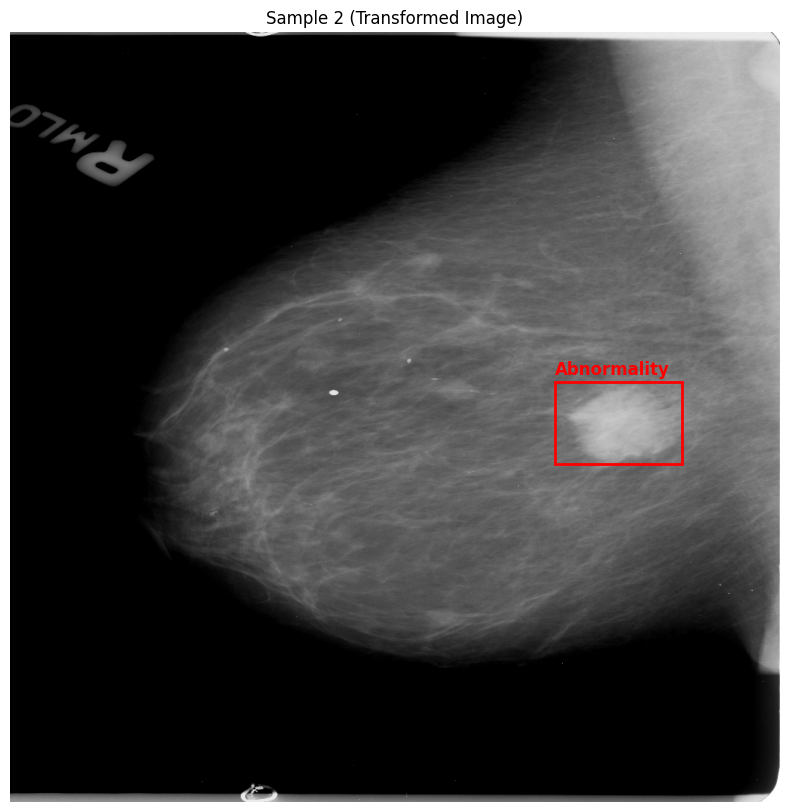

In [32]:
dataset = CBISDDSM_RCNN_Dataset(dataframe=paired_df)

transform_dataset = CBISDDSM_RCNN_Dataset(dataframe=paired_df, transform=rcnn_transform)

check_idx = 2

dataset.visualize_sample(check_idx, title=f"Sample {check_idx} (Original Image)")

transform_dataset.visualize_sample(check_idx, title=f"Sample {check_idx} (Transformed Image)")

In [33]:
unique_patients = paired_df['PatientID_full'].unique()

train_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)

In [34]:
train_df = paired_df[paired_df['PatientID_full'].isin(train_patients)].copy()
test_df = paired_df[paired_df['PatientID_full'].isin(test_patients)].copy()

In [35]:
train_dataset = CBISDDSM_RCNN_Dataset(dataframe=train_df, transform=rcnn_transform)

test_dataset = CBISDDSM_RCNN_Dataset(dataframe=test_df, transform=rcnn_transform)

In [36]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [37]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

In [38]:
def get_object_detection_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


num_classes = 2  # Background or abnormality
model = get_object_detection_model(num_classes)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
print(f"Using device: {device}")

Using device: cuda


In [39]:
checkpoint_dir = '../models/Faster_RCNN/checkpoints'

os.makedirs(checkpoint_dir, exist_ok=True)

In [40]:
completed_dir = '../models/Faster_RCNN/Completed'

os.makedirs(completed_dir, exist_ok=True)

In [42]:
completed_path = None

if len(os.listdir(completed_dir)) > 0:
    while True:
        check = input("Completed directory is not empty. Do you want to use saved model? (y/n): ")

        if check == 'y':
            root = tk.Tk()
            root.withdraw()

            completed_path = filedialog.askopenfilename(initialdir="../models/Faster_RCNN/Completed",
                                                        title="Select a model file",
                                                        filetypes=(("Model Files", "*.pth"), ("All Files", "*.*")))

            if not completed_path:
                print("No model file selected. Starting training from scratch.")
            else:
                print(f"Using saved model from {completed_path}")
            break
        elif check == 'n':
            print("Checking for checkpoints...")
            break

Checking for checkpoints...


In [43]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 10
start_epoch = 0

resume_path = None

if not completed_path and len(os.listdir(checkpoint_dir)) > 0:
    while True:
        check = input("Checkpoint directory is not empty. Do you want to resume training? (y/n): ")

        if check == 'y':
            root = tk.Tk()
            root.withdraw()

            resume_path = filedialog.askopenfilename(initialdir="../models/Faster_RCNN/checkpoints",
                                                     title="Select a checkpoint file",
                                                     filetypes=(("Checkpoint Files", "*.pth"), ("All Files", "*.*")))

            if not resume_path:
                print("No checkpoint file selected. Starting training from scratch.")
            break
        elif check == 'n':
            print("Training will start from scratch.")
            break

if completed_path:
    if os.path.exists(completed_path):
        print(f"Loading model from {completed_path}")
        saved = torch.load(completed_path, map_location=device)
        model.load_state_dict(saved)
        model.eval()
        print("Model loaded successfully.")
elif resume_path:
    if os.path.exists(resume_path):
        print(f"Loading checkpoint from {resume_path}")

        checkpoint = torch.load(resume_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1

        print(f"Resuming training from epoch {start_epoch}")
    else:
        print(f"Checkpoint {resume_path} not found. Starting training from scratch.")

if not completed_path:
    scaler = GradScaler()
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0

        for i, (images, targets) in enumerate(train_loader):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            optimizer.zero_grad()

            with autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', enabled=True):
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())

            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += losses.item()

            if i % 10 == 0:
                print(f"Epoch [{epoch + 1}/{num_epochs}] | Batch [{i}/{len(train_loader)}] | Loss: {losses.item():.4f}")

        lr_scheduler.step()
        print(f"--- Epoch {epoch + 1} Completed | Average Loss: {epoch_loss / len(train_loader):.4f} ---")

        checkpoint_path = os.path.join(checkpoint_dir, f'rcnn_checkpoint_{epoch + 1}.pth')

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_loss
        }

        torch.save(checkpoint, checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")

Epoch [1/10] | Batch [0/303] | Loss: 1.1406
Epoch [1/10] | Batch [10/303] | Loss: 0.1806
Epoch [1/10] | Batch [20/303] | Loss: 0.2638
Epoch [1/10] | Batch [30/303] | Loss: 0.2020
Epoch [1/10] | Batch [40/303] | Loss: 0.2032
Epoch [1/10] | Batch [50/303] | Loss: 0.2186
Epoch [1/10] | Batch [60/303] | Loss: 0.1299
Epoch [1/10] | Batch [70/303] | Loss: 0.1911
Epoch [1/10] | Batch [80/303] | Loss: 0.1561
Epoch [1/10] | Batch [90/303] | Loss: 0.1787
Epoch [1/10] | Batch [100/303] | Loss: 0.1671
Epoch [1/10] | Batch [110/303] | Loss: 0.2473
Epoch [1/10] | Batch [120/303] | Loss: 0.1364
Epoch [1/10] | Batch [130/303] | Loss: 0.1369
Epoch [1/10] | Batch [140/303] | Loss: 0.1208
Epoch [1/10] | Batch [150/303] | Loss: 0.1566
Epoch [1/10] | Batch [160/303] | Loss: 0.1328
Epoch [1/10] | Batch [170/303] | Loss: 0.1280
Epoch [1/10] | Batch [180/303] | Loss: 0.1499
Epoch [1/10] | Batch [190/303] | Loss: 0.1712
Epoch [1/10] | Batch [200/303] | Loss: 0.1251
Epoch [1/10] | Batch [210/303] | Loss: 0.1690

In [44]:
if not completed_path:
    model_save_path = '../models/Faster_RCNN/Completed/Completed_Training.pth'
    torch.save(model.state_dict(), model_save_path)
    print(f"Model weights saved to {model_save_path}")

Model weights saved to ../models/Faster_RCNN/Completed/Completed_Training.pth


In [45]:
def test_and_visualize(model, test_loader, device, confidence_threshold=0.2, idx=0):
    model.eval()

    images, targets = next(iter(test_loader))

    images = list(img.to(device) for img in images)

    with torch.no_grad():
        predictions = model(images)

    img_np = images[idx].cpu().permute(1, 2, 0).numpy()
    # img_np = (img_np * 0.5) + 0.5
    img_np = np.clip(img_np, 0, 1)

    fig, ax = plt.subplots(1, figsize=(12, 12))

    if img_np.shape[-1] == 1:
        ax.imshow(img_np.squeeze(-1), cmap='gray')
    else:
        ax.imshow(img_np)

    # True boxes (Red)
    true_boxes = targets[idx]['boxes'].cpu().numpy()

    for box in true_boxes:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        plt.text(xmin, ymin, 'Actual', color='r', fontsize=12, weight='bold')

    # Predicted boxes (Green)
    predicted_boxes = predictions[idx]['boxes'].cpu().numpy()
    predicted_scores = predictions[idx]['scores'].cpu().numpy()

    for box, score in zip(predicted_boxes, predicted_scores):
        if score >= confidence_threshold:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='g',
                                     facecolor='none')
            ax.add_patch(rect)
            plt.text(xmin, ymin, f'Predicted ({score:.2f} Confidence)', color='g', fontsize=12, weight='bold')
    plt.axis('off')
    plt.title("Test Image and Predictions")

    legend_elements = [Line2D([0], [0], color='r', lw=2, label='Actual'),
                       Line2D([0], [0], color='g', lw=2, label='Predicted')]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.show()

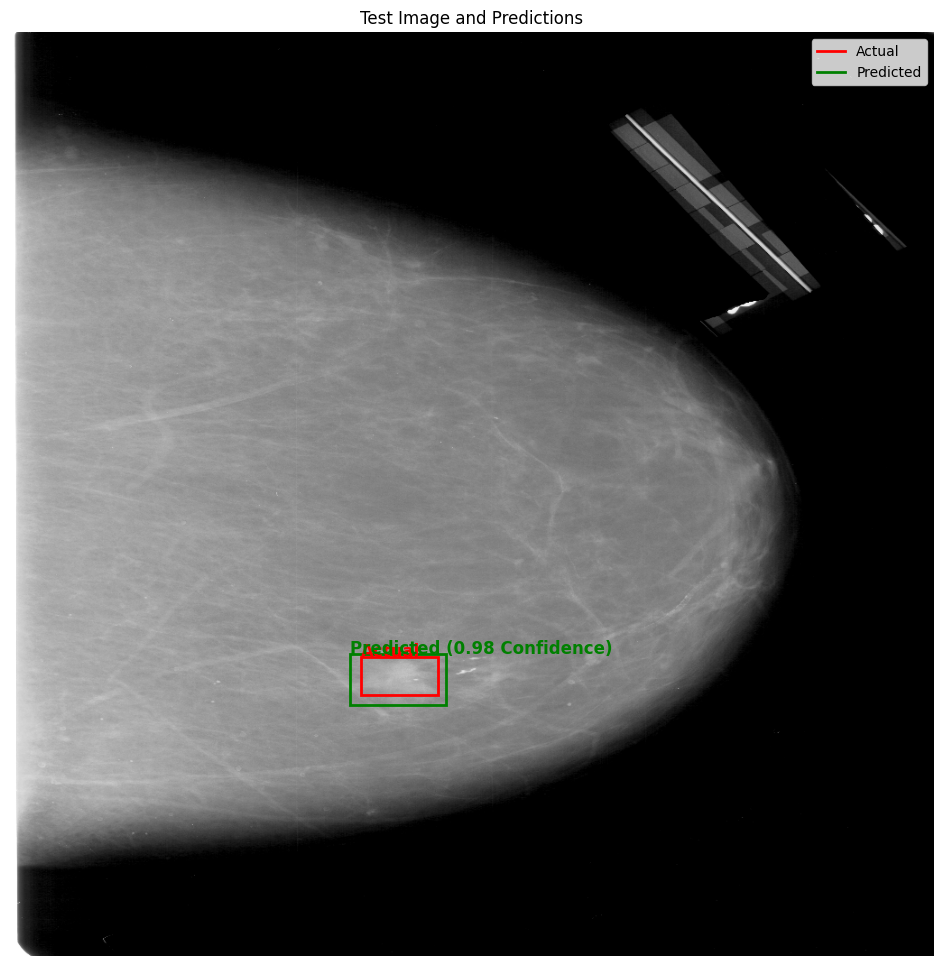

In [47]:
test_and_visualize(model, test_loader, device, idx=0)

In [48]:
def calculate_test_map(model, test_loader, device):
    print("Calculating test set mAP...")
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

    model.eval()

    print(f"Evaluating over {len(test_loader)} batches.")
    with torch.no_grad():
        for imgs, targets in tqdm(test_loader):
            imgs = list(img.to(device) for img in imgs)

            predictions = model(imgs)

            formatted_predictions = []
            for p in predictions:
                formatted_predictions.append(dict(
                    boxes=p['boxes'].cpu(),
                    scores=p['scores'].cpu(),
                    labels=p['labels'].cpu()
                ))

            formatted_targets = []
            for t in targets:
                formatted_targets.append(dict(
                    boxes=t['boxes'].cpu(),
                    labels=t['labels'].cpu()
                ))

            metric.update(formatted_predictions, formatted_targets)

    print("Computing final mAP...")
    results = metric.compute()
    print("Done")

    return results

In [49]:
map_results = calculate_test_map(model, test_loader, device)

Calculating test set mAP...
Evaluating over 76 batches.


100%|██████████| 76/76 [01:36<00:00,  1.27s/it]

Computing final mAP...
Done


In [50]:
print(f"mAP @ IoU=0.50:0.95 (COCO Standard): {map_results['map'].item():.4f}")
print(f"mAP @ IoU=0.50 (PASCAL VOC Standard): {map_results['map_50'].item():.4f}")

mAP @ IoU=0.50:0.95 (COCO Standard): 0.2240
mAP @ IoU=0.50 (PASCAL VOC Standard): 0.5378
